# 01 - Building Convolutional Neural Networks (CNNs) in PyTorch (GPU Accelerated)

This notebook provides a complete hands-on guide to constructing, training, and inspecting **Convolutional Neural Networks (CNNs)** in PyTorch on the **real MNIST dataset** with **CUDA GPU Acceleration**.

---

## Key Learning Objectives:

1. **GPU Acceleration**: Dynamically setting `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')` and moving tensors/models to GPU (`.to(device)`).
2. **Core Building Blocks of CNNs**: 2D Convolutions (`nn.Conv2d`), spatial output math, Max/Avg/Adaptive Pooling.
3. **Real Image Data Pipeline**: Loading and normalizing real images with `torchvision.datasets.MNIST`.
4. **Model Architecture & GPU Training Loop**: LeNet-5 model training with GPU tensor transfers.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as torch_optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.datasets import MNIST

np.random.seed(42)
torch.manual_seed(42)

# GPU Device Selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Using Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


PyTorch Version: 2.11.0+cu128
Using Device: cuda
GPU Name: Tesla T4


## 1. Loading Real Image Data & DataLoader Setup


Train Dataset Size: 60000 real images
Test Dataset Size:  10000 real images


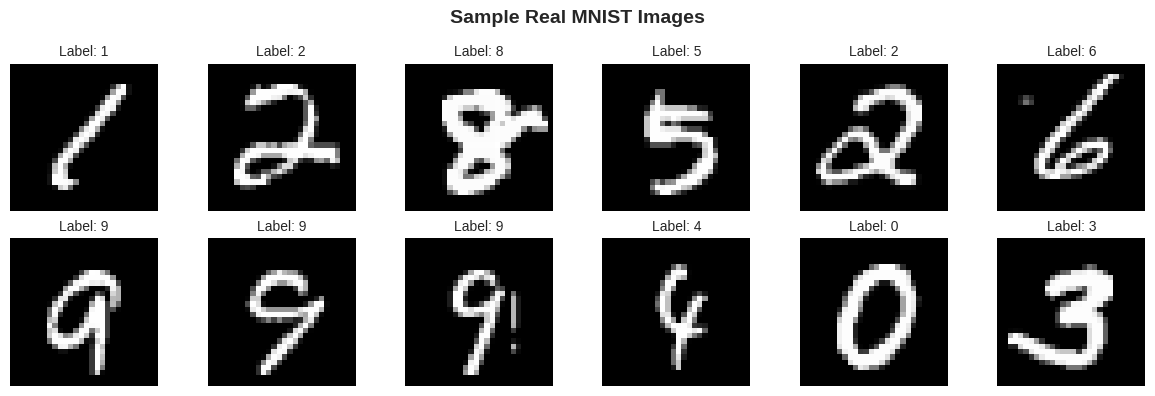

In [15]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.1307,), std=(0.3081,))
])

train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train Dataset Size: {len(train_dataset)} real images")
print(f"Test Dataset Size:  {len(test_dataset)} real images")

# Display sample batch
sample_imgs, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i][0].numpy(), cmap='gray')
    ax.set_title(f"Label: {sample_labels[i].item()}", fontsize=10)
    ax.axis('off')
plt.suptitle("Sample Real MNIST Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Anatomy of `nn.Conv2d` on GPU

Testing 2D Convolution on GPU tensors.


In [16]:
conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1).to(device)
sample_gpu = sample_imgs.to(device)
out1 = conv1(sample_gpu)

print(f"GPU Image Input Shape: {list(sample_gpu.shape)}, Device: {sample_gpu.device}")
print(f"Conv1 Output Shape:     {list(out1.shape)}, Device: {out1.device}")


GPU Image Input Shape: [64, 1, 28, 28], Device: cuda:0
Conv1 Output Shape:     [64, 16, 28, 28], Device: cuda:0


## 3. Building & Moving LeNet-5 Architecture to GPU


In [17]:
class LeNet5MNIST(nn.Module):
    def __init__(self):
        super(LeNet5MNIST, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 16, kernel_size=5, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.classifier(self.feature_extractor(x))

model = LeNet5MNIST().to(device)
print(f"Model successfully loaded on target device: {device}")


Model successfully loaded on target device: cuda


## 4. Accelerated GPU Training Loop on Real MNIST


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch_optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device) # Move mini-batch to GPU
        
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * len(by)
        preds = torch.argmax(out, dim=1)
        correct += (preds == by).sum().item()
        total += len(by)
        
    epoch_tr_loss = running_loss / total
    epoch_tr_acc = correct / total
    
    model.eval()
    t_loss, t_correct, t_total = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            loss = criterion(out, by)
            t_loss += loss.item() * len(by)
            t_correct += (torch.argmax(out, dim=1) == by).sum().item()
            t_total += len(by)
            
    epoch_te_loss = t_loss / t_total
    epoch_te_acc = t_correct / t_total
    
    train_losses.append(epoch_tr_loss)
    test_losses.append(epoch_te_loss)
    train_accs.append(epoch_tr_acc)
    test_accs.append(epoch_te_acc)
    
    print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {epoch_tr_loss:.4f} | Train Acc: {epoch_tr_acc*100:.2f}% | Test Loss: {epoch_te_loss:.4f} | Test Acc: {epoch_te_acc*100:.2f}%")


Epoch 01/10 | Train Loss: 0.2140 | Train Acc: 93.39% | Test Loss: 0.0645 | Test Acc: 98.01%
Epoch 02/10 | Train Loss: 0.0608 | Train Acc: 98.06% | Test Loss: 0.0449 | Test Acc: 98.57%
Epoch 03/10 | Train Loss: 0.0430 | Train Acc: 98.63% | Test Loss: 0.0410 | Test Acc: 98.64%
Epoch 04/10 | Train Loss: 0.0333 | Train Acc: 98.96% | Test Loss: 0.0481 | Test Acc: 98.58%
Epoch 05/10 | Train Loss: 0.0290 | Train Acc: 99.07% | Test Loss: 0.0320 | Test Acc: 98.98%
Epoch 06/10 | Train Loss: 0.0227 | Train Acc: 99.24% | Test Loss: 0.0279 | Test Acc: 99.13%
Epoch 07/10 | Train Loss: 0.0203 | Train Acc: 99.35% | Test Loss: 0.0344 | Test Acc: 99.00%
Epoch 08/10 | Train Loss: 0.0161 | Train Acc: 99.44% | Test Loss: 0.0400 | Test Acc: 98.88%
Epoch 09/10 | Train Loss: 0.0140 | Train Acc: 99.54% | Test Loss: 0.0377 | Test Acc: 98.88%
Epoch 10/10 | Train Loss: 0.0138 | Train Acc: 99.56% | Test Loss: 0.0360 | Test Acc: 99.02%


## 5. Visualizing Curves & Predictions (Moving Tensors back to CPU for Matplotlib)


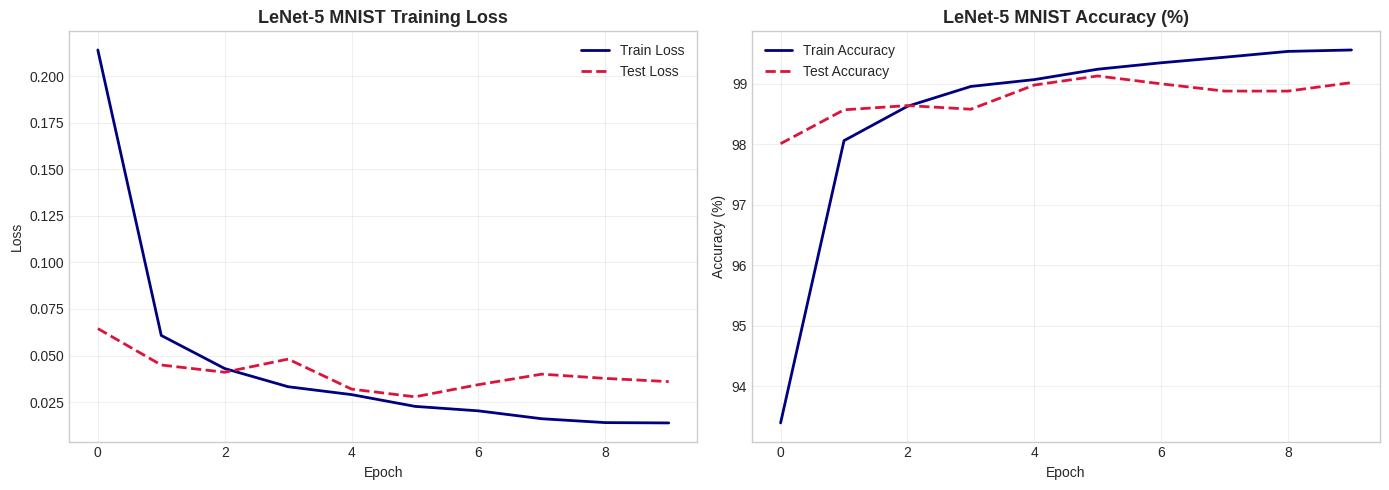

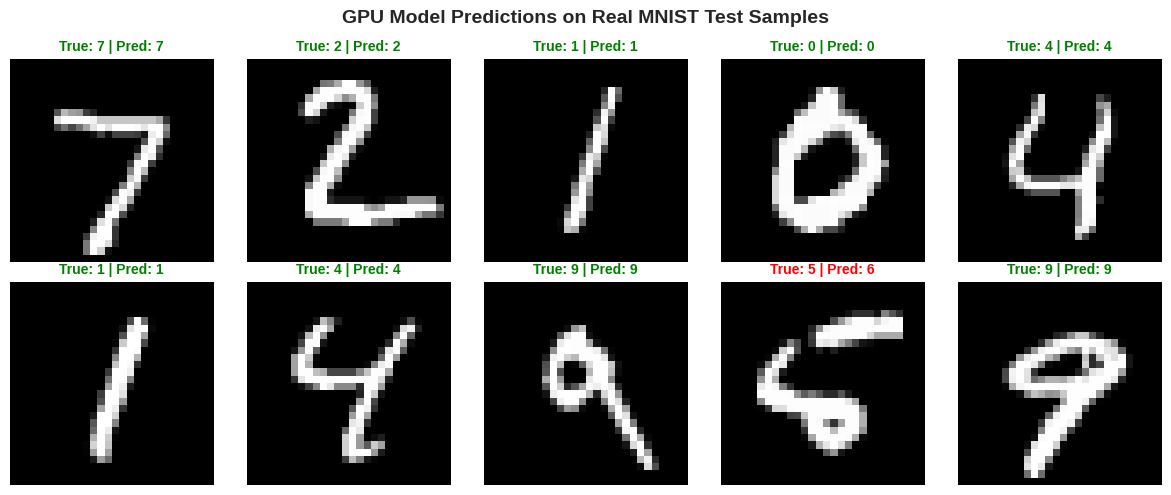

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='navy', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('LeNet-5 MNIST Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in train_accs], label='Train Accuracy', color='navy', linewidth=2)
axes[1].plot([a*100 for a in test_accs], label='Test Accuracy', color='crimson', linestyle='--', linewidth=2)
axes[1].set_title('LeNet-5 MNIST Accuracy (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Predictions on Real Test Images
test_imgs, test_labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    test_preds = torch.argmax(model(test_imgs.to(device)), dim=1).cpu() # Move predictions to CPU for numpy/matplotlib

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(test_imgs[i][0].numpy(), cmap='gray')
    color = 'green' if test_preds[i] == test_labels[i] else 'red'
    ax.set_title(f"True: {test_labels[i].item()} | Pred: {test_preds[i].item()}", color=color, fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle("GPU Model Predictions on Real MNIST Test Samples", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
